# Heart Disease prediction Using Machine Learning



## 1. Install the required package

In [2]:
!pip install -q ucimlrepo


## 2. Import libraries

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")


## 3. Fetch the dataset

In [4]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)


Feature data shape: (303, 13)
Target data shape: (303, 1)


## 4. Metadata and variable information

In [5]:
print("DATASET METADATA")
print("-" * 80)
print(heart_disease.metadata)


DATASET METADATA
--------------------------------------------------------------------------------
{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm f

In [6]:
print("VARIABLE INFORMATION")
print("-" * 80)
display(heart_disease.variables)


VARIABLE INFORMATION
--------------------------------------------------------------------------------


,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


## 5. Combine predictors and target

In [7]:
print("Target column(s):", y.columns.tolist())

df = pd.concat([X, y], axis=1)

print("Combined dataset shape:", df.shape)
display(df.head())


Target column(s): ['num']
Combined dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.30,3,0.00,6.00,0
1,67,1,4,160,286,0,2,108,1,1.50,2,3.00,3.00,2
2,67,1,4,120,229,0,2,129,1,2.60,2,2.00,7.00,1
3,37,1,3,130,250,0,0,187,0,3.50,3,0.00,3.00,0
4,41,0,2,130,204,0,2,172,0,1.40,1,0.00,3.00,0


## 6. Basic data checks

In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())


Number of rows: 303
Number of columns: 14

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [9]:
print("DATA TYPES")
display(df.dtypes.to_frame(name="Data Type"))


DATA TYPES


,Data Type
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [11]:
display(df.head())
display(df.tail())


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.30,3,0.00,6.00,0
1,67,1,4,160,286,0,2,108,1,1.50,2,3.00,3.00,2
2,67,1,4,120,229,0,2,129,1,2.60,2,2.00,7.00,1
3,37,1,3,130,250,0,0,187,0,3.50,3,0.00,3.00,0
4,41,0,2,130,204,0,2,172,0,1.40,1,0.00,3.00,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
298,45,1,1,110,264,0,0,132,0,1.20,2,0.00,7.00,1
299,68,1,4,144,193,1,0,141,0,3.40,2,2.00,7.00,2
300,57,1,4,130,131,0,0,115,1,1.20,2,1.00,7.00,3
301,57,0,2,130,236,0,2,174,0,0.00,2,1.00,3.00,1
302,38,1,3,138,175,0,0,173,0,0.00,1,NaN,3.00,0


## 7. Missing-value analysis

In [12]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Values", ascending=False)

display(missing_summary)


,Missing Values,Missing Percentage
ca,4,1.32
thal,2,0.66
cp,0,0.00
trestbps,0,0.00
age,0,0.00
sex,0,0.00
fbs,0,0.00
chol,0,0.00
restecg,0,0.00
thalach,0,0.00


In [13]:
missing_only = missing_summary[missing_summary["Missing Values"] > 0]

missing_only


,Missing Values,Missing Percentage
ca,4,1.32
thal,2,0.66


## 8. Duplicate-record check

In [14]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)])
else:
    print("No duplicate rows were found.")


Number of duplicate rows: 0
No duplicate rows were found.


## 9. Unique-value check

In [15]:
unique_summary = pd.DataFrame({
    "Unique Values": df.nunique(dropna=False)
}).sort_values("Unique Values")

display(unique_summary)


,Unique Values
sex,2
fbs,2
exang,2
restecg,3
slope,3
thal,4
cp,4
ca,5
num,5
oldpeak,40


In [16]:
low_cardinality_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 10
]

for col in low_cardinality_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).sort_index())



sex
sex
0     97
1    206
Name: count, dtype: int64

cp
cp
1     23
2     50
3     86
4    144
Name: count, dtype: int64

fbs
fbs
0    258
1     45
Name: count, dtype: int64

restecg
restecg
0    151
1      4
2    148
Name: count, dtype: int64

exang
exang
0    204
1     99
Name: count, dtype: int64

slope
slope
1    142
2    140
3     21
Name: count, dtype: int64

ca
ca
0.00    176
1.00     65
2.00     38
3.00     20
NaN       4
Name: count, dtype: int64

thal
thal
3.00    166
6.00     18
7.00    117
NaN       2
Name: count, dtype: int64

num
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


## 10. Prepare the binary target

In [17]:
target_column = y.columns[0]

print("Original target column:", target_column)
print("\nOriginal target distribution:")
print(df[target_column].value_counts(dropna=False).sort_index())

df["heart_disease_binary"] = np.where(df[target_column] > 0, 1, 0)

print("\nBinary target distribution:")
print(df["heart_disease_binary"].value_counts().sort_index())

print("\nBinary target percentages:")
print((df["heart_disease_binary"].value_counts(normalize=True).sort_index() * 100).round(2))


Original target column: num

Original target distribution:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Binary target distribution:
heart_disease_binary
0    164
1    139
Name: count, dtype: int64

Binary target percentages:
heart_disease_binary
0   54.13
1   45.87
Name: proportion, dtype: float64


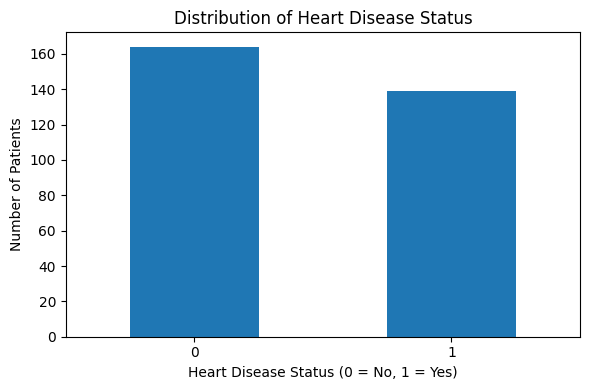

In [18]:
target_counts = df["heart_disease_binary"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Distribution of Heart Disease Status")
plt.xlabel("Heart Disease Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 11. Descriptive statistics

In [19]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_columns].describe().T)


,count,mean,std,min,25%,50%,75%,max
age,303.00,54.44,9.04,29.00,48.00,56.00,61.00,77.00
sex,303.00,0.68,0.47,0.00,0.00,1.00,1.00,1.00
cp,303.00,3.16,0.96,1.00,3.00,3.00,4.00,4.00
trestbps,303.00,131.69,17.60,94.00,120.00,130.00,140.00,200.00
chol,303.00,246.69,51.78,126.00,211.00,241.00,275.00,564.00
fbs,303.00,0.15,0.36,0.00,0.00,0.00,0.00,1.00
restecg,303.00,0.99,0.99,0.00,0.00,1.00,2.00,2.00
thalach,303.00,149.61,22.88,71.00,133.50,153.00,166.00,202.00
exang,303.00,0.33,0.47,0.00,0.00,0.00,1.00,1.00
oldpeak,303.00,1.04,1.16,0.00,0.00,0.80,1.60,6.20


In [20]:
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

if categorical_columns:
    display(df[categorical_columns].describe().T)
else:
    print("No non-numeric columns were identified.")


No non-numeric columns were identified.
